In [1]:
# %% ============================================================
# CELL 1: Imports & Configuration
# ===============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
 
DATA_PATH = Path("data")
 
# Ensemble weights to test
WEIGHT_PAIRS = [
    (1.0, 0.0),   # Model A only
    (0.0, 1.0),   # Model B only
    (0.7, 0.3),   # Favor Model A
    (0.5, 0.5),   # Equal blend
    (0.3, 0.7),   # Favor Model B
    (0.6, 0.4),
    (0.8, 0.2),
]

In [2]:
# %% ============================================================
# CELL 2: Load Data
# ===============================================================
ground_truth = pd.read_csv(DATA_PATH / "test_ground_truth.csv").sort_values("date_id").reset_index(drop=True)
target_pairs = pd.read_csv(DATA_PATH / "target_pairs.csv")
target_cols = [c for c in ground_truth.columns if c.startswith("target_")]
 
# Load predictions from both models
pred_a = pd.read_csv("predictions_lstm_v3.csv").sort_values("date_id").reset_index(drop=True)
pred_b = pd.read_csv("predictions_feature_forecast_raw.csv").sort_values("date_id").reset_index(drop=True)
 
print(f"Model A predictions: {pred_a.shape}")
print(f"Model B predictions: {pred_b.shape}")
print(f"Ground truth:        {ground_truth.shape}")
print(f"Target columns:      {len(target_cols)}")

Model A predictions: (114, 425)
Model B predictions: (134, 425)
Ground truth:        (134, 425)
Target columns:      424


In [3]:
# %% ============================================================
# CELL 3: Align Predictions
# ===============================================================
# Find common dates across both models and ground truth
common_dates = set(pred_a["date_id"]) & set(pred_b["date_id"]) & set(ground_truth["date_id"])
common_dates = sorted(common_dates)
 
pred_a_aligned = pred_a[pred_a["date_id"].isin(common_dates)].sort_values("date_id").reset_index(drop=True)
pred_b_aligned = pred_b[pred_b["date_id"].isin(common_dates)].sort_values("date_id").reset_index(drop=True)
gt_aligned = ground_truth[ground_truth["date_id"].isin(common_dates)].sort_values("date_id").reset_index(drop=True)
 
print(f"\nCommon dates: {len(common_dates)} (from {min(common_dates)} to {max(common_dates)})")
print(f"Aligned shapes: A={pred_a_aligned.shape}, B={pred_b_aligned.shape}, GT={gt_aligned.shape}")


Common dates: 114 (from 1847 to 1960)
Aligned shapes: A=(114, 425), B=(114, 425), GT=(114, 425)


In [4]:
# %% ============================================================
# CELL 4: Competition Metric
# ===============================================================
def competition_score(pred_df, gt_df, target_cols, silent=False):
    """Exact replication of Kaggle grading metric (Sharpe of daily rank correlations)."""
    pred = pred_df[target_cols].copy()
    gt = gt_df[target_cols].copy()
 
    daily_corrs = []
    for i in range(len(pred)):
        gt_row = gt.iloc[i]
        pred_row = pred.iloc[i]
 
        valid = gt_row.notna()
        if valid.sum() < 2:
            continue
 
        gt_valid = gt_row[valid]
        pred_valid = pred_row[valid]
 
        if gt_valid.std(ddof=0) == 0 or pred_valid.std(ddof=0) == 0:
            continue
 
        corr = np.corrcoef(
            pred_valid.rank(method="average"),
            gt_valid.rank(method="average")
        )[0, 1]
        daily_corrs.append(corr)
 
    daily_corrs = np.array(daily_corrs)
    if len(daily_corrs) == 0 or daily_corrs.std(ddof=0) == 0:
        return 0.0, daily_corrs
 
    sharpe = daily_corrs.mean() / daily_corrs.std(ddof=0)
 
    if not silent:
        print(f"  Daily rank corr: mean={daily_corrs.mean():.4f}, "
              f"std={daily_corrs.std():.4f}, Sharpe={sharpe:.4f}, "
              f"days={len(daily_corrs)}")
 
    return sharpe, daily_corrs

In [5]:
# %% ============================================================
# CELL 5: Ensemble Weight Sweep
# ===============================================================
print("=" * 60)
print("ENSEMBLE WEIGHT SWEEP")
print("=" * 60)
 
results = []
best_sharpe = -float("inf")
best_weights = None
best_daily = None
 
for w_a, w_b in WEIGHT_PAIRS:
    # Create ensemble predictions
    ensemble = pred_a_aligned.copy()
    for col in target_cols:
        ensemble[col] = w_a * pred_a_aligned[col] + w_b * pred_b_aligned[col]
 
    sharpe, daily = competition_score(ensemble, gt_aligned, target_cols, silent=True)
    results.append((w_a, w_b, sharpe))
 
    label = f"  A={w_a:.1f}, B={w_b:.1f}: Sharpe={sharpe:.4f}"
    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_weights = (w_a, w_b)
        best_daily = daily
        label += " ★"
 
    print(label)
 
print(f"\nBest: A={best_weights[0]:.1f}, B={best_weights[1]:.1f} → Sharpe={best_sharpe:.4f}")

ENSEMBLE WEIGHT SWEEP
  A=1.0, B=0.0: Sharpe=0.3018 ★
  A=0.0, B=1.0: Sharpe=0.1859
  A=0.7, B=0.3: Sharpe=0.2994
  A=0.5, B=0.5: Sharpe=0.2857
  A=0.3, B=0.7: Sharpe=0.2606
  A=0.6, B=0.4: Sharpe=0.2937
  A=0.8, B=0.2: Sharpe=0.3009

Best: A=1.0, B=0.0 → Sharpe=0.3018


In [6]:
# %% ============================================================
# CELL 6: Generate Best Ensemble Predictions
# ===============================================================
w_a, w_b = best_weights
final_ensemble = pred_a_aligned.copy()
for col in target_cols:
    final_ensemble[col] = w_a * pred_a_aligned[col] + w_b * pred_b_aligned[col]
 
print("=" * 60)
print(f"FINAL ENSEMBLE (A={w_a:.1f}, B={w_b:.1f}):")
print("=" * 60)
final_sharpe, final_daily = competition_score(final_ensemble, gt_aligned, target_cols)
 
# Per-lag breakdown
print("\nPer-target Spearman:")
for lag in sorted(target_pairs["lag"].unique()):
    lag_targets = target_pairs.loc[target_pairs["lag"] == lag, "target"].tolist()
    lag_corrs = []
    for col in lag_targets:
        if col not in final_ensemble.columns or col not in gt_aligned.columns:
            continue
        mask = gt_aligned[col].notna()
        if mask.sum() < 5:
            continue
        c, _ = spearmanr(final_ensemble.loc[mask, col], gt_aligned.loc[mask, col])
        lag_corrs.append(c)
    pos = sum(1 for c in lag_corrs if c > 0)
    print(f"  Lag {lag}: mean={np.nanmean(lag_corrs):.4f}, positive={pos}/{len(lag_corrs)}")

FINAL ENSEMBLE (A=1.0, B=0.0):
  Daily rank corr: mean=0.0537, std=0.1777, Sharpe=0.3018, days=114

Per-target Spearman:
  Lag 1: mean=0.0192, positive=54/106
  Lag 2: mean=0.0559, positive=78/106
  Lag 3: mean=0.0614, positive=74/106
  Lag 4: mean=0.0779, positive=73/106


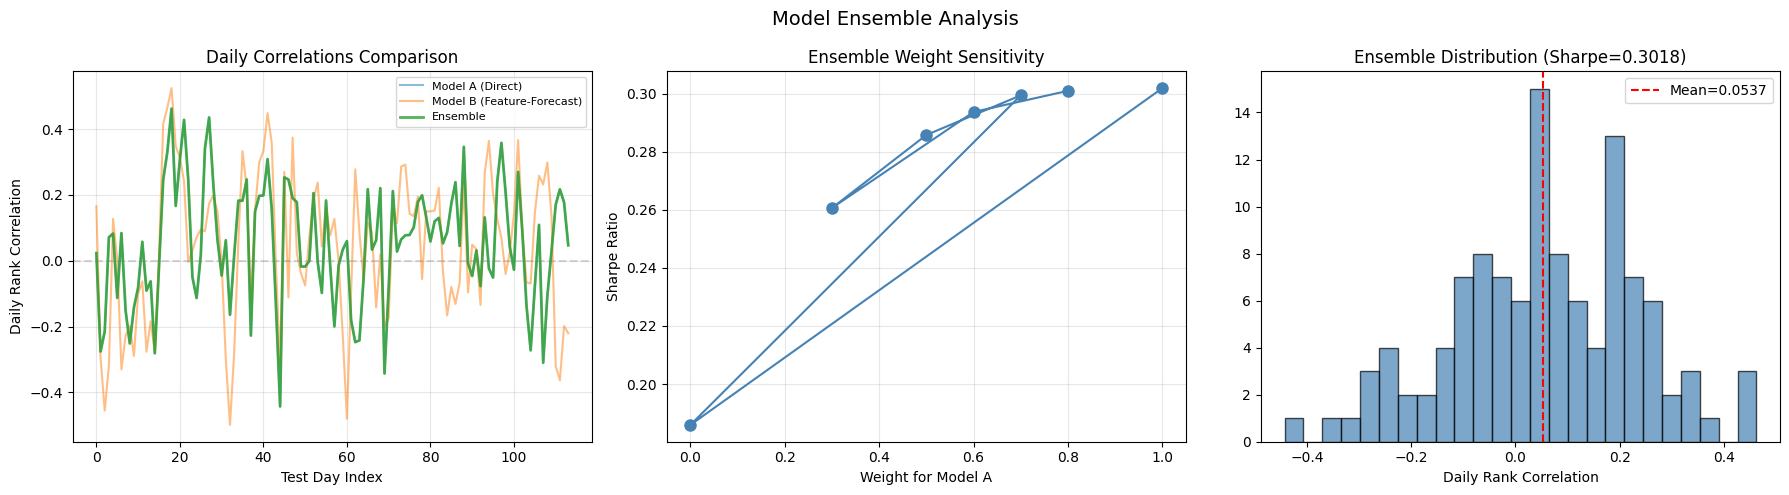

In [7]:
# %% ============================================================
# CELL 7: Visualize
# ===============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Compare individual vs ensemble
_, daily_a = competition_score(pred_a_aligned, gt_aligned, target_cols, silent=True)
_, daily_b = competition_score(pred_b_aligned, gt_aligned, target_cols, silent=True)
 
axes[0].plot(daily_a, label="Model A (Direct)", alpha=0.5)
axes[0].plot(daily_b, label="Model B (Feature-Forecast)", alpha=0.5)
axes[0].plot(final_daily, label="Ensemble", alpha=0.8, linewidth=2)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.3)
axes[0].set_xlabel("Test Day Index")
axes[0].set_ylabel("Daily Rank Correlation")
axes[0].set_title("Daily Correlations Comparison")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
 
# Weight sweep visualization
weights_a = [r[0] for r in results]
sharpes = [r[2] for r in results]
axes[1].plot(weights_a, sharpes, "o-", color="steelblue", markersize=8)
axes[1].set_xlabel("Weight for Model A")
axes[1].set_ylabel("Sharpe Ratio")
axes[1].set_title("Ensemble Weight Sensitivity")
axes[1].grid(True, alpha=0.3)
 
# Distribution of ensemble daily correlations
axes[2].hist(final_daily, bins=25, edgecolor="black", alpha=0.7, color="steelblue")
axes[2].axvline(final_daily.mean(), color="red", linestyle="--",
                label=f"Mean={final_daily.mean():.4f}")
axes[2].set_xlabel("Daily Rank Correlation")
axes[2].set_title(f"Ensemble Distribution (Sharpe={final_sharpe:.4f})")
axes[2].legend()
 
plt.suptitle("Model Ensemble Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("ensemble_results.png", dpi=150)
plt.show()

In [8]:
# %% ============================================================
# CELL 8: Save Results
# ===============================================================
final_ensemble.to_csv("predictions_ensemble.csv", index=False)
print(f"\nSaved ensemble predictions to predictions_ensemble.csv")
print(f"\n{'='*60}")
print(f"  Model A (Direct LSTM):           Sharpe = {competition_score(pred_a_aligned, gt_aligned, target_cols, silent=True)[0]:.4f}")
print(f"  Model B (Feature-Forecast LSTM): Sharpe = {competition_score(pred_b_aligned, gt_aligned, target_cols, silent=True)[0]:.4f}")
print(f"  Ensemble ({best_weights[0]:.1f}/{best_weights[1]:.1f}):              Sharpe = {final_sharpe:.4f}")
print(f"{'='*60}")


Saved ensemble predictions to predictions_ensemble.csv

  Model A (Direct LSTM):           Sharpe = 0.3018
  Model B (Feature-Forecast LSTM): Sharpe = 0.1859
  Ensemble (1.0/0.0):              Sharpe = 0.3018
